In [ ]:
#Importing datas
import sys
!{sys.executable} -m pip install pandas seaborn matplotlib scipy

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Dataset.csv")

In [ ]:
# Presentation of the data used
df[['CountryName', 'GDP_PerCapita_2015 US$', 'SuicideRate_2015']]

,CountryName,GDP_PerCapita_2015 US$,SuicideRate_2015
0,Afghanistan,578.466353,4.8
1,Angola,4166.979684,5.0
2,Albania,3952.830781,6.0
3,United Arab Emirates,38663.383810,2.8
4,Argentina,13789.060420,8.8
...,...,...,...
155,Vanuatu,2721.635936,4.5
156,Samoa,4155.279353,4.5
157,South Africa,5730.934174,11.8
158,Zambia,1332.194321,6.1


In [ ]:
#Checking for missing values
df["CountryName"].isnull()

,CountryName
0,False
1,False
2,False
3,False
4,False
...,...
155,False
156,False
157,False
158,False


In [ ]:
#Counting missing values
df["CountryName"].isnull().value_counts()

,count
CountryName,
False,160


In [ ]:
#Checking for duplicated values
df.duplicated().any()

np.False_

In [ ]:
#Adding duplicates to remove them
duplicates = df.sample(5, random_state=60)
print(duplicates)

          CountryName Country Code  GDP_PerCapita_2000 US$  SuicideRate_2000  \
141              Togo          TGO              302.206394               9.6   
150            Uganda          UGA              261.868998              11.1   
79             Kuwait          KWT            18439.900390               2.0   
105         Nicaragua          NIC             1007.501429              17.2   
115  Papua New Guinea          PNG              602.186902               7.1   

     GDP_PerCapita_2005 US$  SuicideRate_2005  GDP_PerCapita_2010 US$  \
141              406.400951               9.9              533.508792   
150              325.590374              10.5              622.498846   
79             35590.704070               2.3            38577.381660   
105             1162.290113              14.4             1503.867544   
115              749.186396               5.8             1949.348560   

     SuicideRate_2010  GDP_PerCapita_2015 US$  SuicideRate_2015  \
141          

In [ ]:
# Showing the duplicates values added
df_with_duplicates = pd.concat([df, duplicates], ignore_index=True)
df_with_duplicates.shape

(165, 12)

In [ ]:
# Showing in a table where duplicates values are
df_with_duplicates[df_with_duplicates.duplicated()]

,CountryName,Country Code,GDP_PerCapita_2000 US$,SuicideRate_2000,GDP_PerCapita_2005 US$,SuicideRate_2005,GDP_PerCapita_2010 US$,SuicideRate_2010,GDP_PerCapita_2015 US$,SuicideRate_2015,GDP_PerCapita_2016 US$,SuicideRate_2016
160,Togo,TGO,302.206394,9.6,406.400951,9.9,533.508792,9.5,570.680737,9.4,587.874409,9.6
161,Uganda,UGA,261.868998,11.1,325.590374,10.5,622.498846,10.5,709.021039,9.9,608.705735,9.9
162,Kuwait,KWT,18439.900390,2.0,35590.704070,2.3,38577.381660,1.9,29869.529390,2.3,27653.164400,2.3
163,Nicaragua,NIC,1007.501429,17.2,1162.290113,14.4,1503.867544,12.5,2049.851415,12.2,2107.574238,12.2
164,Papua New Guinea,PNG,602.186902,7.1,749.186396,5.8,1949.348560,5.4,2679.326711,6.0,2509.629007,6.0


In [ ]:
#Cleaning the duplicates value
df_clean = df_with_duplicates.drop_duplicates ()

In [ ]:
#Checking if the cleaning worked
df_clean.duplicated().any()

np.False_

In [113]:
#Outlier handling
Q1 = df_clean['SuicideRate_2015'].quantile(0.25)
Q3 = df_clean['SuicideRate_2015'].quantile(0.75)
IQR = Q3 - Q1

df_2015 = df_clean[
    (df_clean['SuicideRate_2015'] >= Q1 - 1.5 * IQR) &
    (df_clean['SuicideRate_2015'] <= Q3 + 1.5 * IQR)
]

print("Countries before outlier removal:", len(df_clean))
print("Countries after outlier removal:", len(df_2015))
print("Outliers removed:", len(df_clean) - len(df_2015))

Countries before outlier removal: 160
Countries after outlier removal: 155
Outliers removed: 5


In [134]:
#Checking if the cleaning of the outliers worked
print("Before:", len(df_clean))
print("After:", len(df_2015))

Before: 160
After: 155


In [135]:
#Dividing them in 3 bands by GDP Per Capita in 2015
df_2015['gdp_band'] = pd.cut(
    df_2015['GDP_PerCapita_2015 US$'],
    bins=[0, 4000, 8000, float('inf')],
    labels=['Low', 'Medium', 'High'])
print(df_2015[['GDP_PerCapita_2015 US$', 'gdp_band']].head(10))

   GDP_PerCapita_2015 US$ gdp_band
0              578.466353      Low
1             4166.979684   Medium
2             3952.830781      Low
3            38663.383810     High
4            13789.060420     High
5             3607.296697      Low
6            14526.588080     High
7            56748.420260     High
8            44176.671740     High
9             5500.320497   Medium


/tmp/ipykernel_7106/782490596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015['gdp_band'] = pd.cut(


In [136]:
#Sorting the data by GDP per capita in 2015
df_2015.sort_values(by='GDP_PerCapita_2015 US$', ascending=False)

,CountryName,Country Code,GDP_PerCapita_2000 US$,SuicideRate_2000,GDP_PerCapita_2005 US$,SuicideRate_2005,GDP_PerCapita_2010 US$,SuicideRate_2010,GDP_PerCapita_2015 US$,SuicideRate_2015,GDP_PerCapita_2016 US$,SuicideRate_2016,gdp_band
86,Luxembourg,LUX,48735.995490,16.8,80289.696410,14.3,104965.306100,12.9,100428.368000,14.7,101305.527700,13.5,High
27,Switzerland,CHE,37868.323060,21.8,54952.673720,20.8,74605.721020,16.2,82081.597120,17.1,80037.503040,17.2,High
107,Norway,NOR,38146.715390,13.3,66775.394400,12.7,87770.266840,12.6,74521.569930,12.4,70941.525270,12.2,High
119,Qatar,QAT,29976.117040,3.4,51455.594190,3.2,67403.160300,6.1,63039.016550,6.5,57163.060990,6.6,High
67,Ireland,IRL,26241.364610,12.4,50878.223610,11.9,48715.176860,12.0,61995.422780,11.5,63197.082370,11.5,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,Niger,NER,158.704975,4.6,249.927930,4.9,347.343041,4.9,360.853384,4.7,362.131132,4.6,Low
10,Burundi,BDI,136.463971,7.1,151.681463,8.4,234.235647,9.0,305.549773,8.9,282.149681,9.1,Low
130,Somalia,SOM,NaN,4.7,NaN,4.8,NaN,4.3,293.465423,4.7,295.933654,4.7,Low
43,Eritrea,ERI,308.133784,11.6,388.595123,10.4,667.744178,9.0,NaN,8.1,NaN,7.9,NaN


In [137]:
#Aggregating by GDP band
by_gdp_band = df_2015.groupby('gdp_band')['SuicideRate_2015'].sum()
print(by_gdp_band)

gdp_band
Low       496.5
Medium    205.3
High      650.7
Name: SuicideRate_2015, dtype: float64


/tmp/ipykernel_7106/2535251047.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_gdp_band = df_2015.groupby('gdp_band')['SuicideRate_2015'].sum()


In [138]:
#Creating summary statistics for the data
"""Visualize summary statistics of the dataset:

For each variable:
Count: Amount of times the variable is present.
Mean: Mathematical average of the values of a specific variable.
Std: Standard deviation of a specific variable.
Min: Minimum Value.
25%, 50%, 75%: Quartiles (Q1, median, Q3).
Max: Maximum value.
"""
df.describe()

,GDP_PerCapita_2000 US$,SuicideRate_2000,GDP_PerCapita_2005 US$,SuicideRate_2005,GDP_PerCapita_2010 US$,SuicideRate_2010,GDP_PerCapita_2015 US$,SuicideRate_2015,GDP_PerCapita_2016 US$,SuicideRate_2016
count,155.000000,160.000000,158.000000,160.000000,158.000000,160.000000,158.000000,160.000000,158.000000,160.000000
mean,6788.322390,11.019375,10276.172249,10.395625,13155.709352,9.853125,13245.538494,9.436250,13182.438191,9.328125
std,10294.136840,8.999326,15629.233543,8.342212,18632.212134,7.212375,18274.795495,6.271363,18275.609163,6.063015
min,124.460800,1.300000,151.681463,1.200000,234.235647,0.300000,293.465423,0.700000,282.149681,0.500000
25%,585.058819,5.075000,927.030322,4.875000,1405.176373,4.900000,1771.373651,4.800000,1907.004360,4.700000
50%,1728.705340,8.450000,3119.452593,8.200000,4677.061160,8.000000,5453.512177,8.100000,5147.627196,7.850000
75%,7368.332777,13.325000,11060.205395,12.525000,13725.915143,12.625000,14690.653115,12.500000,15054.012527,12.650000
max,48735.995490,52.600000,80289.696410,51.600000,104965.306100,40.000000,100428.368000,34.900000,101305.527700,31.900000


In [139]:
#Printing the country summary statistics
print("===== COUNTRY SUMMARY STATISTIC =====")
print("Count (CountryName):", df["CountryName"].count())
print("Mean (SuicideRate_2015):", df["SuicideRate_2015"].mean())
print("Median (SuicideRate_2015):", df["SuicideRate_2015"].median())
print("Mode (GDP_PerCapita_2015 US$):\n", df["GDP_PerCapita_2015 US$"].mode())
print("Standard Deviation (SuicideRate_2015):", df["SuicideRate_2015"].std())
print("Variance (SuicideRate_2015):", df["SuicideRate_2015"].var())
print("Minimum (GDP_PerCapita_2015 US$):", df["GDP_PerCapita_2015 US$"].min())
print("Maximum (GDP_PerCapita_2015 US$):", df["GDP_PerCapita_2015 US$"].max())
# Note: 'Suicides No' column was not found, assuming 'SuicideRate_2015' is intended for sum as well
print("Sum (SuicideRate_2015):", df["SuicideRate_2015"].sum())
print("25th Percentile (GDP_PerCapita_2015 US$):", df["GDP_PerCapita_2015 US$"].quantile(0.25))
print("75th Percentile (GDP_PerCapita_2015 US$):", df["GDP_PerCapita_2015 US$"].quantile(0.75))
print("Correlation (SuicideRate_2015 vs GDP_PerCapita_2015 US$):", df["SuicideRate_2015"].corr(df["GDP_PerCapita_2015 US$"]))
print("Covariance(SuicideRate_2015 vs GDP_PerCapita_2015 US$):\n", df["SuicideRate_2015"].cov(df["GDP_PerCapita_2015 US$"]))

===== COUNTRY SUMMARY STATISTIC =====
Count (CountryName): 160
Mean (SuicideRate_2015): 9.436250000000001
Median (SuicideRate_2015): 8.1
Mode (GDP_PerCapita_2015 US$):
 0         293.465423
1         305.549773
2         360.853384
3         380.404293
4         380.597033
           ...      
153     61995.422780
154     63039.016550
155     74521.569930
156     82081.597120
157    100428.368000
Name: GDP_PerCapita_2015 US$, Length: 158, dtype: float64
Standard Deviation (SuicideRate_2015): 6.271363362752388
Variance (SuicideRate_2015): 39.32999842767295
Minimum (GDP_PerCapita_2015 US$): 293.4654226
Maximum (GDP_PerCapita_2015 US$): 100428.368
Sum (SuicideRate_2015): 1509.8000000000002
25th Percentile (GDP_PerCapita_2015 US$): 1771.37365075
75th Percentile (GDP_PerCapita_2015 US$): 14690.653115
Correlation (SuicideRate_2015 vs GDP_PerCapita_2015 US$): 0.2440908477485541
Covariance(SuicideRate_2015 vs GDP_PerCapita_2015 US$):
 28019.05597370191


/tmp/ipykernel_7106/2988370693.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gdp_band', y='SuicideRate_2015', data=plot_df, palette='viridis')


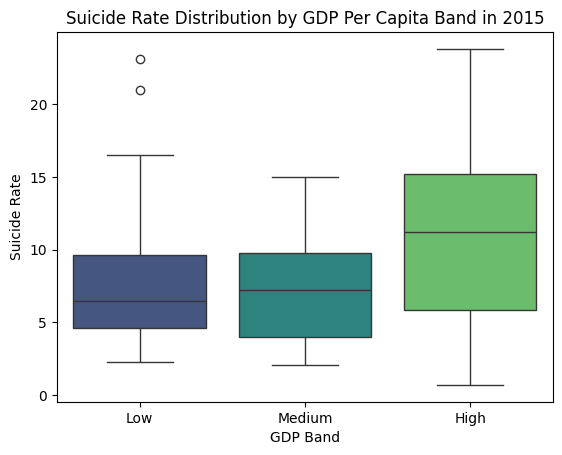

In [140]:
#Boxplot for Suicide Rate by GDP band
plot_df = df_2015.dropna(subset=['gdp_band']) # Drop rows where gdp_band is NaN
sns.boxplot(x='gdp_band', y='SuicideRate_2015', data=plot_df, palette='viridis')
plt.title("Suicide Rate Distribution by GDP Per Capita Band in 2015")
plt.xlabel("GDP Band")
plt.ylabel("Suicide Rate")
plt.show()

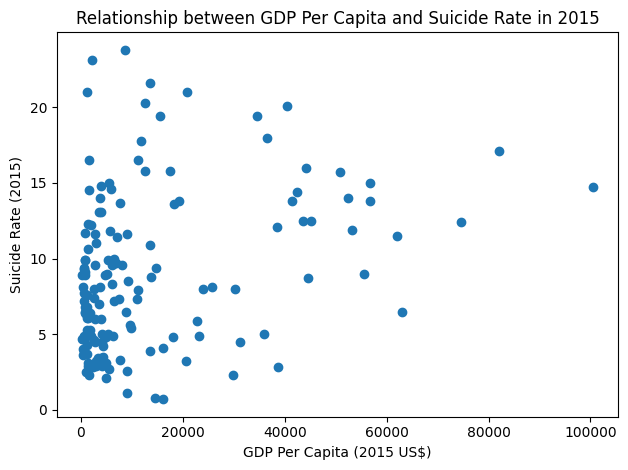

In [141]:
#Scatterplot: Relationship between GDP and Suicide Rate in 2015
plt.scatter(df_2015['GDP_PerCapita_2015 US$'], df_2015['SuicideRate_2015'])
plt.title("Relationship between GDP Per Capita and Suicide Rate in 2015")
plt.xlabel("GDP Per Capita (2015 US$)")
plt.ylabel("Suicide Rate (2015)")
plt.tight_layout()
plt.show()

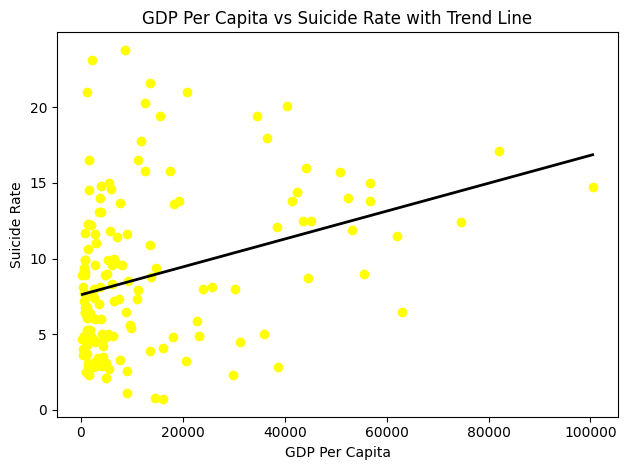

In [142]:
import numpy as np
from sklearn.preprocessing import StandardScaler

#Drop rows with NaN values in the relevant columns to avoid issues with polyfit
plot_df_scatter = df_2015.dropna(subset=['GDP_PerCapita_2015 US$', 'SuicideRate_2015'])

x = plot_df_scatter['GDP_PerCapita_2015 US$']
y = plot_df_scatter['SuicideRate_2015']

#Scale the x data to improve polyfit convergence
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x.values.reshape(-1, 1)).flatten()

plt.scatter(x, y, color='yellow')

#Fit polynomial to scaled x and original y
z_scaled = np.polyfit(x_scaled, y, 1)  # linear trend line
p_scaled = np.poly1d(z_scaled)

#To plot the trend line on the original scale, we need to apply the inverse scaling
x_fit_original_scale = np.linspace(x.min(), x.max(), 100)
x_fit_scaled = scaler.transform(x_fit_original_scale.reshape(-1, 1)).flatten()
y_fit = p_scaled(x_fit_scaled)

plt.plot(x_fit_original_scale, y_fit, color='black', linewidth=2)
plt.title("GDP Per Capita vs Suicide Rate with Trend Line")
plt.xlabel("GDP Per Capita")
plt.ylabel("Suicide Rate")
plt.tight_layout()
plt.show()

<Axes: >

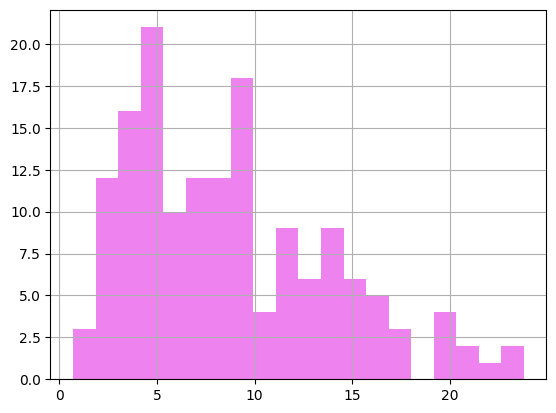

In [143]:
#Histogram — distribution of suicide rates
df_2015['SuicideRate_2015'].hist(color='violet', bins=20)


Columns used for 2015 correlation heatmap: ['GDP_PerCapita_2015 US$', 'SuicideRate_2015']


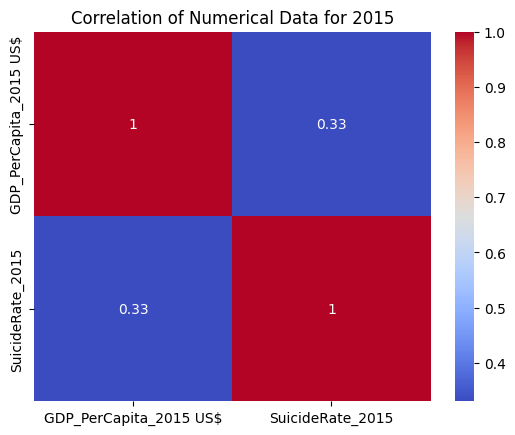

In [144]:
#Heatmap — correlation between all numerical columns explicitly for 2015
#Identify columns specifically for 2015
columns_for_2015_correlation = [col for col in df_2015.columns if '2015' in col and df_2015[col].dtype in ['float64', 'int64']]

print(f"Columns used for 2015 correlation heatmap: {columns_for_2015_correlation}")

#Create a temporary DataFrame with only 2015 numerical columns
df_2015_filtered_for_heatmap = df_2015[columns_for_2015_correlation]

#Generate the heatmap for these specific 2015 numerical columns
sns.heatmap(df_2015_filtered_for_heatmap.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Data for 2015')
plt.show()

/tmp/ipykernel_7106/3034392536.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for band, group in df_2015.groupby('gdp_band'):


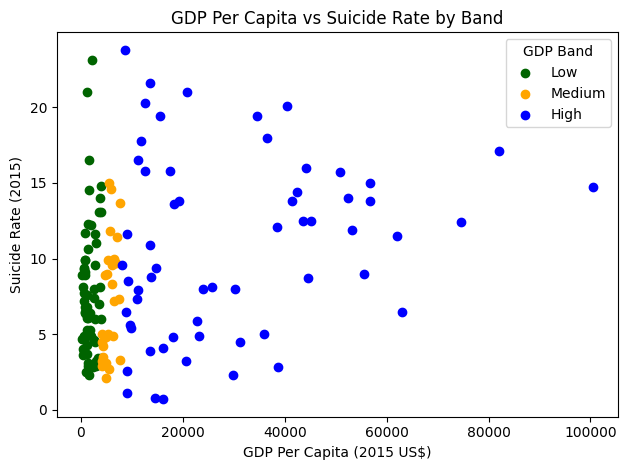

In [145]:
#Scatterplot grouped by GDP band
colors = {'Low': 'darkgreen', 'Medium': 'orange', 'High': 'blue'}

for band, group in df_2015.groupby('gdp_band'):
    plt.scatter(group['GDP_PerCapita_2015 US$'], group['SuicideRate_2015'],
                label=band, color=colors[band])

plt.title("GDP Per Capita vs Suicide Rate by Band")
plt.xlabel("GDP Per Capita (2015 US$)")
plt.ylabel("Suicide Rate (2015)")
plt.legend(title="GDP Band")
plt.tight_layout()
plt.show()


/tmp/ipykernel_7106/4157435222.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_band = df_2015.groupby('gdp_band')['SuicideRate_2015'].mean()


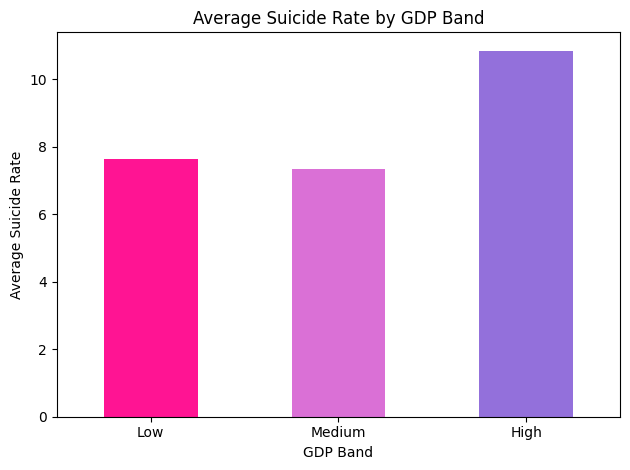

In [146]:
#Bar chart — average suicide rate per band
avg_by_band = df_2015.groupby('gdp_band')['SuicideRate_2015'].mean()

avg_by_band.plot(kind='bar', color=['deeppink', 'orchid', 'mediumpurple'])
plt.title("Average Suicide Rate by GDP Band")
plt.xlabel("GDP Band")
plt.ylabel("Average Suicide Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


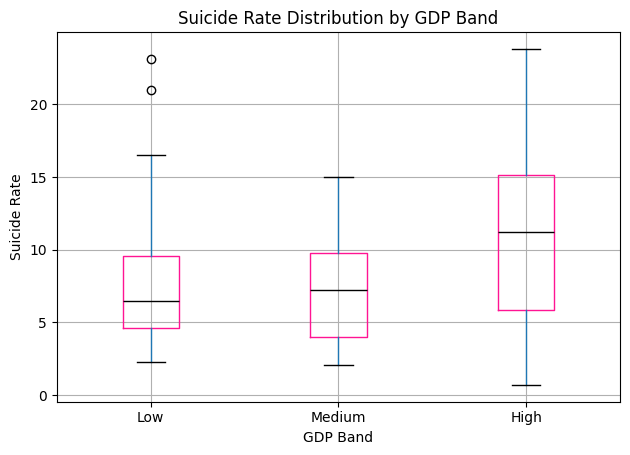

In [147]:
#Boxplot — spread of suicide rates per band
df_2015.boxplot(column='SuicideRate_2015', by='gdp_band',
                boxprops=dict(color='deeppink'),
                medianprops=dict(color='black'))
plt.title("Suicide Rate Distribution by GDP Band")
plt.suptitle("")  # removes default subtitle
plt.xlabel("GDP Band")
plt.ylabel("Suicide Rate")
plt.tight_layout()
plt.show()


/tmp/ipykernel_7106/710327553.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (band, group) in zip(axes, df_2015.groupby('gdp_band')):


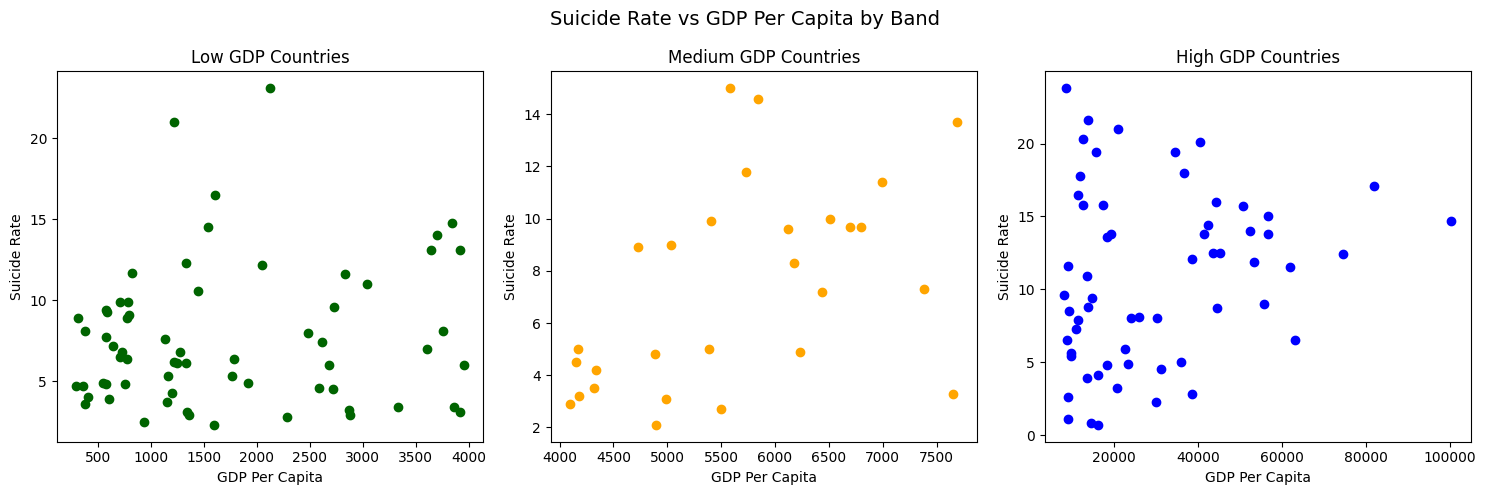

In [148]:
# 3 separate scatterplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (band, group) in zip(axes, df_2015.groupby('gdp_band')):
    ax.scatter(group['GDP_PerCapita_2015 US$'], group['SuicideRate_2015'],
               color=colors[band])
    ax.set_title(f'{band} GDP Countries')
    ax.set_xlabel("GDP Per Capita")
    ax.set_ylabel("Suicide Rate")

plt.suptitle("Suicide Rate vs GDP Per Capita by Band", fontsize=14)
plt.tight_layout()
plt.show()